# Fairness — removing a sensitive attribute
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/24_fairness_transform.ipynb)

`RBIGFairTransformer` removes information about a sensitive attribute
`A` from the features at a chosen strength. This notebook shows the
central case the estimator exists for: a **second-order (variance)
leak** where the groups have *equal means* but *unequal variances*. A
linear projection cannot remove it; distributional `transport` can.

We measure leakage as **A-predictability** — the ROC-AUC of a boosted
classifier trying to recover `A` from the transformed features
(0.5 = perfectly removed).

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

from rbig import RBIGFairTransformer, make_variance_leak

plt.style.use("seaborn-v0_8-paper")


def a_predictability(X, A):
    """ROC-AUC of recovering A from X (0.5 = removed)."""
    return float(
        cross_val_score(
            GradientBoostingClassifier(random_state=0), X, A, cv=3, scoring="roc_auc"
        ).mean()
    )

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: equal means, unequal variances

Group 1's features are scaled up relative to group 0. The group means
coincide, so no linear direction separates them — but the variance
gives `A` away.

In [3]:
X, meta = make_variance_leak(n_samples=1600, seed=0)
A = meta["A"]

proj = RBIGFairTransformer(strategy="projection", n_layers=10, random_state=0).fit(X, A=A)
tran = RBIGFairTransformer(strategy="transport", n_layers=15, random_state=0).fit(X, A=A)
X_proj = proj.transform(X)
X_tran = tran.transform(X, A=A)

auc = {
    "raw": a_predictability(X, A),
    "projection": a_predictability(X_proj, A),
    "transport": a_predictability(X_tran, A),
}

## Leakage before vs after

Left: the first two feature dimensions colored by `A` — the variance
difference is visible. Right: A-predictability per strategy; only
`transport` reaches chance (0.5).

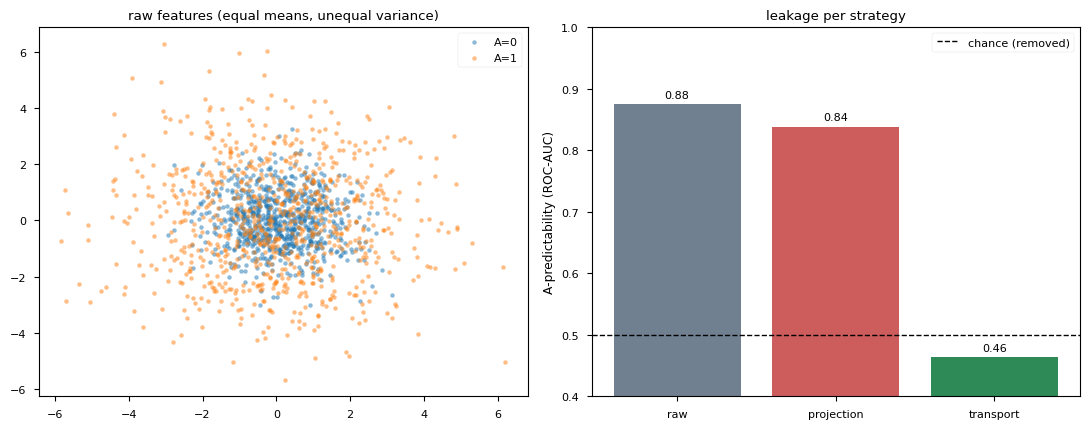

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4))
ax0.scatter(X[A == 0, 0], X[A == 0, 1], s=8, alpha=0.5, label="A=0")
ax0.scatter(X[A == 1, 0], X[A == 1, 1], s=8, alpha=0.5, label="A=1")
ax0.set_title("raw features (equal means, unequal variance)")
ax0.legend(fontsize=8)

bars = ax1.bar(auc.keys(), auc.values(), color=["slategray", "indianred", "seagreen"])
ax1.axhline(0.5, color="k", ls="--", lw=1, label="chance (removed)")
ax1.set_ylim(0.4, 1.0)
ax1.set_ylabel("A-predictability (ROC-AUC)")
ax1.set_title("leakage per strategy")
ax1.legend(fontsize=8)
for b, v in zip(bars, auc.values(), strict=True):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
for k, v in auc.items():
    print(f"{k:>12}: A-predictability = {v:.3f}")

         raw: A-predictability = 0.876
  projection: A-predictability = 0.839
   transport: A-predictability = 0.464


## Takeaways

- `projection` removes only the **linear** A-correlated direction; on a
  pure variance leak it barely moves the needle. `transport` matches
  the full per-group distributions and drives A-predictability to
  chance. See the alpha-Pareto table in the
  [benchmarks](../benchmarks.md).
- The `alpha` knob blends `α·X_fair + (1−α)·X` for a fairness–utility
  trade-off. There is no free lunch: when `I(A; Y) > 0`, removing A
  necessarily removes some Y-signal. Use `conditional` (transport
  within Y-strata) to preserve the task signal when labels are
  available.
- For pipelines, pass `sensitive_col=` to consume `A` from a column of
  `X`; for metadata routing, use `set_fit_request`/`set_transform_request`.
  See the [fairness guide](../guides/fairness.md).